# Playbook: U-Net na ortofotomapie z Łomianek

Zestaw ćwiczeń do **poziomu 3** (wykład: `03_segmentacja_unet.md`, 20 slajdów). Na wykładzie U-Net uczy się na zbiorze VDD, a potem segmentuje ortofotomapę z Tapias (Kolumbia).
Tutaj robisz to, co robi się w pracy: **bierzesz gotowy model i puszczasz go na zdjęciu, którego nigdy nie widział**: `dane/lomianki_ortofoto.tif`
(łąki, ściernisko, kępy drzew i krzewów, droga gruntowa, **bez zabudowy**; 1700 × 1700 px, piksel 0,1 m, EPSG:32634).
Na końcu wiesz, czy takiemu wynikowi można ufać, i masz go w QGIS-ie.

**To playbook, nie ćwiczenie z programowania.** Cały kod jest już w notebooku i pochodzi z wykładu (przy zadaniu jest numer slajdu). Ty:

1. uruchamiasz komórki po kolei od góry: `Shift + Enter`,
2. w komórkach **TWOJA KOLEJ** zmieniasz tylko to, co stoi między liniami `ZMIEŃ TU`: liczby, słowa w cudzysłowie, `True` / `False`. Resztę zostaw,
3. patrzysz na wynik i wpisujesz odpowiedzi w komórce **Twoja odpowiedź** pod zadaniem (dwuklik, wpisz, `Shift + Enter`).

Komórki oznaczone **GOTOWE** tylko uruchamiasz. Nie musisz ich czytać.

**Czego tu nie ma: uczenia modelu.** Trwa kilkadziesiąt minut i wymaga zbioru VDD (2 GB, zbiór z dostępem na zgłoszenie). Model jest już wyuczony i leży w `modele/unet_vdd_resnet34.pt` (powstaje w notebooku `03_segmentacja_unet.ipynb`).
Uwaga o liczbach: model w `modele/` pochodzi z innego przebiegu uczenia niż liczby na slajdach, więc Twoje wyniki mogą się od nich trochę różnić. Patrz na to, co wynik znaczy, a nie na trzecią cyfrę.

Wyniki, które zapiszesz, trafiają do `wyniki/zadania_unet/`. Obliczenia trwają sekundy (na komputerze bez GPU do minuty).

## Playbook w 6 krokach

To jest procedura, którą stosujesz do **każdego** nowego zdjęcia. Zadania idą dokładnie po niej.

| Krok | Pytanie | Zadania | Slajdy wykładu |
|---|---|---|---|
| 1. Skala | Czy piksel zdjęcia jest taki, na jakim uczono model? | 1 | 5, 17 |
| 2. Próba na kadrze | Co model robi na małym fragmencie? Jak ustawić kafelki? Gdzie jest niepewny? | 2–5 | 7, 14, 18 |
| 3. Całość do GeoTIFF-a | Jak dostać wynik z georeferencją i czy leży na siatce zdjęcia? | 6 | 17 |
| 4. Ocena bez prawdy terenowej | Czy wynik ma sens? Czego model nie zmyśla, a czego nie widzi? | 7–8 | 13, 16, 18, 20 |
| 5. Do QGIS-a | Jak zamienić wynik na poligony, zapisać GeoPackage i obejrzeć go na mapie? | 9–10 | 19 |
| 6. Decyzja | Oddać wynik, poprawić go, czy douczyć model? | 11 | 20 |

## Gdy coś nie działa

| Objaw | Co zrobić |
|---|---|
| `FileNotFoundError` w komórce startowej | Brakuje zdjęcia albo modelu. W terminalu: `python pobierz_lomianki.py` i `python pobierz_dane.py`; model dostajesz od prowadzącego. |
| `NameError: name '...' is not defined` | Pominąłeś komórkę wyżej. Uruchom notebook od góry (menu *Run All* albo *Restart* i *Run All*). |
| Komórka liczy się dłużej niż 2 minuty (gwiazdka `[*]`) | Na komputerze bez GPU liczy się wolniej. Poczekaj albo przerwij (*Interrupt*). |
| Zmieniłem liczbę, a wynik ten sam | Trzeba ponownie uruchomić **tę** komórkę (`Shift + Enter`). |
| Wpisałem złą nazwę klasy | Nazwy są dokładnie takie: `inne`, `ściana`, `droga`, `roślinność`, `pojazd`, `dach`, `woda`. |

## Zadanie 1. uruchom po kolei, bez zmian

Trzy komórki: importy i ustawienia, funkcje z wykładu, wczytanie modelu i zdjęć.

In [5]:
import time
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import segmentation_models_pytorch as smp
import torch
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle
from rasterio.features import shapes
from rasterio.windows import Window
from shapely.geometry import shape
from skimage.filters import threshold_otsu

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

LOMIANKI = Path("data/lomianki_ortofoto.tif")        # zdjęcie do zadań
TAPIAS = Path("data/tapias_ortofoto.tif")            # zdjęcie z wykładu (do porównań)
PLIK_MODELU = Path("modele/unet_vdd_resnet34.pt")    # gotowy model z notebooka 03
KATALOG = Path("wyniki/zadania_unet")                # tu trafiają Twoje wyniki
KATALOG.mkdir(parents=True, exist_ok=True)

brakuje = [str(p) for p in (LOMIANKI, TAPIAS, PLIK_MODELU) if not p.exists()]
if brakuje:
    raise FileNotFoundError("Brakuje plików: " + ", ".join(brakuje) + "\n"
                            "Zdjęcia: w terminalu `python pobierz_lomianki.py` i `python pobierz_dane.py`. "
                            "Model dostajesz od prowadzącego (powstaje w notebooku 03).")

# Klasy VDD (slajd 4): wartość piksela w masce = indeks na liście
NAZWY_KLAS = ["inne", "ściana", "droga", "roślinność", "pojazd", "dach", "woda"]
KOLORY_KLAS = ["#8c8c8c", "#e63c3c", "#ffffff", "#28a028", "#0078ff", "#ff9600", "#00dcdc"]
KOLORY_RGB = np.array([[int(k[i:i + 2], 16) for i in (1, 3, 5)] for k in KOLORY_KLAS], dtype=np.uint8)
N_KLAS = len(NAZWY_KLAS)
ROSLINNOSC = NAZWY_KLAS.index("roślinność")

GSD_MODELU_M = 0.12      # piksel, na jakim uczono model (slajd 5)
KAFELEK = 256            # bok kafelka w pikselach (slajd 7)

URZADZENIE = torch.device("mps" if torch.backends.mps.is_available()
                          else "cuda" if torch.cuda.is_available() else "cpu")
print("Urządzenie:", URZADZENIE, "| pliki na miejscu: OK")

Urządzenie: mps | pliki na miejscu: OK


In [6]:
# ---------- Funkcje z wykładu (numer slajdu w komentarzu) ----------

SREDNIA = np.array([0.485, 0.456, 0.406], dtype=np.float32)       # normalizacja jak w ImageNet (slajd 8)
ODCHYLENIE = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def do_tensora(rgb):
    """RGB uint8 (H,W,3) → tensor float32 (3,H,W) znormalizowany jak w ImageNet."""
    return torch.from_numpy(((rgb.astype(np.float32) / 255 - SREDNIA) / ODCHYLENIE).transpose(2, 0, 1).copy())


def siatka_kafelkow(wys, szer, rozmiar=KAFELEK, krok=192):
    """Lista (y, x) lewych-górnych rogów kafelków pokrywających cały obraz (slajd 7)."""
    def pozycje(n):
        if n <= rozmiar:
            return [0]
        p = list(range(0, n - rozmiar + 1, krok))
        if p[-1] != n - rozmiar:
            p.append(n - rozmiar)                         # ostatni kafelek dosunięty do krawędzi
        return p
    return [(y, x) for y in pozycje(wys) for x in pozycje(szer)]


def okno_hanna(rozmiar):
    w = np.hanning(rozmiar + 2)[1:-1].astype(np.float32)        # środek kafelka liczy się mocno, brzeg prawie wcale
    return np.outer(w, w)


@torch.no_grad()
def predykcja_kafelkami(model, rgb, kafelek=KAFELEK, krok=KAFELEK // 2, paczka=16, tta=True):
    """Prawdopodobieństwa klas (N_KLAS, H, W) dla obrazu RGB uint8 dowolnego rozmiaru (slajd 14)."""
    model.eval()
    h, w = rgb.shape[:2]
    if h < kafelek or w < kafelek:                              # obraz mniejszy niż kafelek — dopełniamy
        rgb = cv2.copyMakeBorder(rgb, 0, max(0, kafelek - h), 0, max(0, kafelek - w), cv2.BORDER_REPLICATE)
    H, W = rgb.shape[:2]
    suma = np.zeros((N_KLAS, H, W), dtype=np.float32)
    waga = np.zeros((H, W), dtype=np.float32)
    okno = okno_hanna(kafelek)
    pozycje = siatka_kafelkow(H, W, kafelek, krok)
    for i in range(0, len(pozycje), paczka):
        poz = pozycje[i:i + paczka]
        x = torch.stack([do_tensora(rgb[y:y + kafelek, xx:xx + kafelek]) for y, xx in poz]).to(URZADZENIE)
        p = model(x).softmax(1)
        if tta:
            p = (p + model(x.flip(-1)).softmax(1).flip(-1)) / 2      # TTA: odbicie poziome i z powrotem
        for (y, xx), pk in zip(poz, p.cpu().numpy()):
            suma[:, y:y + kafelek, xx:xx + kafelek] += pk * okno     # prawdopodobieństwa ważone oknem Hanna
            waga[y:y + kafelek, xx:xx + kafelek] += okno
    return (suma / waga)[:, :h, :w]


def segmentuj_ortomozaik(sciezka_wej, sciezka_klas, sciezka_pewnosci, model, blok=1024, margines=128):
    """RGB GeoTIFF → GeoTIFF z klasami (uint8, 255 = brak danych) i GeoTIFF z pewnością (0–100) (slajd 17).
    Zwraca liczbę pikseli każdej klasy i GSD ortomozaiku."""
    with rasterio.open(sciezka_wej) as src:
        if src.count < 3 or src.dtypes[0] != "uint8":
            raise ValueError(f"Oczekuję 8-bitowego RGB, a jest: {src.count} pasm, {src.dtypes[0]}")
        if src.crs is None or not src.crs.is_projected:
            raise ValueError("Ortomozaik musi mieć układ metryczny (np. UTM, PL-2000) — inaczej nie znamy GSD.")
        gsd = src.res[0]
        if abs(gsd / GSD_MODELU_M - 1) > 0.25:
            raise ValueError(f"GSD ortomozaiku to {gsd:.3f} m, a model uczyliśmy w {GSD_MODELU_M} m — "
                             "najpierw zmień rozdzielczość ortomozaiku.")
        profil = dict(driver="GTiff", height=src.height, width=src.width, count=1, dtype="uint8", crs=src.crs,
                      transform=src.transform, nodata=255, compress="deflate", tiled=True, blockxsize=256, blockysize=256)
        piksele = np.zeros(N_KLAS, dtype=np.int64)

        with rasterio.open(sciezka_klas, "w", **profil) as wyj_klasy, rasterio.open(sciezka_pewnosci, "w", **profil) as wyj_pewn:
            for y0 in range(0, src.height, blok):
                for x0 in range(0, src.width, blok):
                    szer, wys = min(blok, src.width - x0), min(blok, src.height - y0)
                    x1, y1 = max(0, x0 - margines), max(0, y0 - margines)                 # blok z marginesem
                    x2, y2 = min(src.width, x0 + szer + margines), min(src.height, y0 + wys + margines)
                    rgb = np.moveaxis(src.read([1, 2, 3], window=Window(x1, y1, x2 - x1, y2 - y1)), 0, -1)
                    p = predykcja_kafelkami(model, rgb)
                    w = np.s_[y0 - y1:y0 - y1 + wys, x0 - x1:x0 - x1 + szer]              # wycinamy sam blok, bez marginesu
                    waznie = ~(rgb[w] == 0).all(axis=-1)                                  # czarne tło = brak danych
                    klasy = np.where(waznie, p.argmax(0)[w], 255).astype(np.uint8)
                    pewnosc = np.where(waznie, np.round(p.max(0)[w] * 100), 255).astype(np.uint8)
                    okno = Window(x0, y0, szer, wys)
                    wyj_klasy.write(klasy, 1, window=okno)
                    wyj_pewn.write(pewnosc, 1, window=okno)
                    piksele += np.bincount(klasy[waznie], minlength=N_KLAS)
            wyj_klasy.write_colormap(1, {i: (*map(int, kolor), 255) for i, kolor in enumerate(KOLORY_RGB)})
    return piksele, gsd


def klasy_do_poligonow(sciezka_klas, min_pow_m2=2.0):
    """Raster klas → poligony z atrybutami klasa, nazwa, pow_m2 (slajd 19)."""
    with rasterio.open(sciezka_klas) as src:
        klasy, gsd, transform, crs = src.read(1), src.res[0], src.transform, src.crs
    rekordy = [{"geometry": shape(g), "klasa": int(v)} for g, v in shapes(klasy, mask=klasy != 255, transform=transform)]
    gdf = gpd.GeoDataFrame(rekordy, crs=crs)
    gdf["geometry"] = gdf.geometry.simplify(gsd)                # bez „schodków" z siatki rastra
    gdf["nazwa"] = gdf["klasa"].map(dict(enumerate(NAZWY_KLAS)))
    gdf["pow_m2"] = gdf.geometry.area.round(2)
    return gdf[gdf["pow_m2"] >= min_pow_m2].reset_index(drop=True)


def roslinnosc_exg(rgb, waznie, prog="otsu"):
    """Metoda z poziomu 1: ExG + próg. prog="otsu" liczy próg automatycznie (tylko z ważnych pikseli), liczba = próg ręczny."""
    R, G, B = (rgb[..., i].astype(np.float32) for i in range(3))
    exg = (2 * G - R - B) / (R + G + B + 1e-6)
    t = threshold_otsu(exg[waznie]) if prog == "otsu" else float(prog)
    return (exg > t) & waznie, float(t)


# ---------- Pomocnicze: wczytanie, tabele, rysunki ----------

def wczytaj_zdjecie(sciezka):
    """Zwraca: rgb (H,W,3 uint8), waznie (H,W bool; False = czarne tło bez danych), gsd [m/piksel]."""
    with rasterio.open(sciezka) as src:
        rgb = np.moveaxis(src.read([1, 2, 3]), 0, -1)
        gsd = src.res[0]
    return rgb, ~(rgb == 0).all(axis=-1), gsd


def zaladuj_model(plik=PLIK_MODELU):
    zapis = torch.load(plik, map_location="cpu", weights_only=True)
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=N_KLAS)
    model.load_state_dict(zapis["state_dict"])
    return model.to(URZADZENIE).eval()


def wczytaj_raster(sciezka):
    with rasterio.open(sciezka) as src:
        return src.read(1)


def tabela_klas(klasy, gsd):
    """Powierzchnia [ha] i udział [%] każdej klasy (bez pikseli 255 = brak danych)."""
    piksele = np.bincount(klasy[klasy != 255], minlength=N_KLAS)
    return pd.DataFrame({"powierzchnia [ha]": piksele * gsd ** 2 / 1e4, "udział [%]": piksele / piksele.sum() * 100},
                        index=NAZWY_KLAS).round({"powierzchnia [ha]": 3, "udział [%]": 2})


def legenda():
    return [Patch(facecolor=k, edgecolor="0.4", label=n) for k, n in zip(KOLORY_KLAS, NAZWY_KLAS)]


def pokaz_klasy(ax, klasy, tytul=""):
    """Mapa klas w kolorach VDD; piksele 255 (brak danych) zostają puste."""
    ax.imshow(np.ma.masked_equal(klasy, 255), cmap=ListedColormap(KOLORY_KLAS), vmin=0, vmax=N_KLAS - 1, interpolation="nearest")
    ax.set_title(tytul); ax.axis("off")


def nakladka_klas(rgb, klasy, alfa=0.5):
    """Zdjęcie z półprzezroczystą maską klas (do oceny wzrokowej)."""
    wynik = (1 - alfa) * rgb + alfa * KOLORY_RGB[np.where(klasy == 255, 0, klasy)]
    wynik[klasy == 255] = 0
    return wynik.astype(np.uint8)


print("Gotowe: funkcje wczytane")

Gotowe: funkcje wczytane


Model: U-Net z enkoderem ResNet34, 24.4 mln parametrów, 7 klas
Łomianki: 1700 x 1700 px, piksel 10.0 cm, czarne tło (brak danych): 7.1%
Tapias:   1731 x 1731 px, piksel 12.0 cm, czarne tło (brak danych): 7.6%


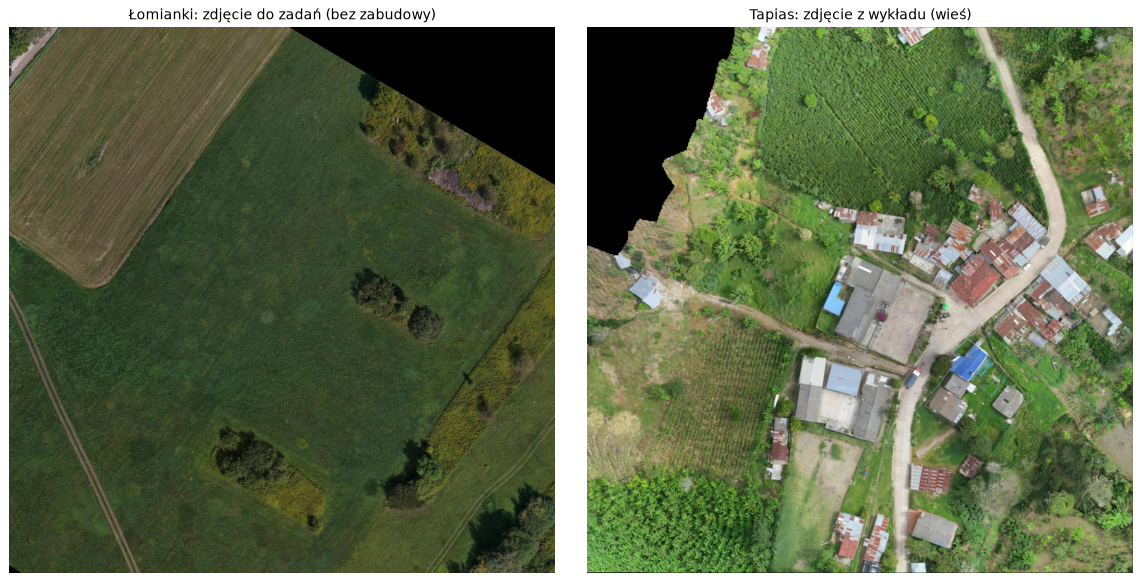

In [4]:
model = zaladuj_model()
rgb_lom, waznie_lom, gsd_lom = wczytaj_zdjecie(LOMIANKI)
rgb_tap, waznie_tap, gsd_tap = wczytaj_zdjecie(TAPIAS)

print(f"Model: U-Net z enkoderem ResNet34, {sum(p.numel() for p in model.parameters()) / 1e6:.1f} mln parametrów, 7 klas")
print(f"Łomianki: {rgb_lom.shape[1]} x {rgb_lom.shape[0]} px, piksel {gsd_lom * 100:.1f} cm, czarne tło (brak danych): {(~waznie_lom).mean():.1%}")
print(f"Tapias:   {rgb_tap.shape[1]} x {rgb_tap.shape[0]} px, piksel {gsd_tap * 100:.1f} cm, czarne tło (brak danych): {(~waznie_tap).mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 6.4))
ax[0].imshow(rgb_lom); ax[0].set_title("Łomianki: zdjęcie do zadań (bez zabudowy)")
ax[1].imshow(rgb_tap); ax[1].set_title("Tapias: zdjęcie z wykładu (wieś)")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

## Krok 2. Próba na kadrze

### Zadanie 2. Kafelki: jak się nakładają



,krok [px],kafelków,średnio widzianych razy
0,256,49,1.1
1,192,81,1.8
2,128,169,3.8
3,64,576,13.1


Dla kroku 192 px: 81 kafelków; bok kafelka = 25.6 m (Łomianki) i 30.7 m (Tapias)


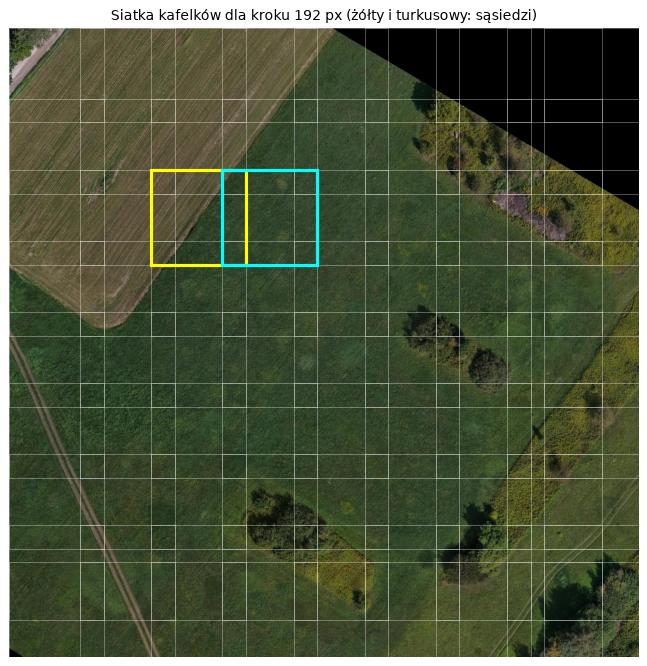

In [7]:
# ==================== ZMIEŃ TU ====================
KROK = 192        # odstęp między kafelkami w pikselach; spróbuj: 256, 192, 128, 64
# ===================================================

h, w = rgb_lom.shape[:2]
tabela = pd.DataFrame({"krok [px]": [256, 192, 128, 64]})
tabela["kafelków"] = [len(siatka_kafelkow(h, w, KAFELEK, k)) for k in tabela["krok [px]"]]
tabela["średnio widzianych razy"] = (tabela["kafelków"] * KAFELEK ** 2 / (h * w)).round(1)
display(tabela)

kafelki = siatka_kafelkow(h, w, KAFELEK, KROK)
print(f"Dla kroku {KROK} px: {len(kafelki)} kafelków; bok kafelka = {KAFELEK * gsd_lom:.1f} m (Łomianki) i {KAFELEK * gsd_tap:.1f} m (Tapias)")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(rgb_lom)
for y, x in kafelki:
    ax.add_patch(Rectangle((x, y), KAFELEK, KAFELEK, fill=False, edgecolor="white", lw=0.5, alpha=0.5))
for (y, x), kolor in zip(kafelki[20:22], ["yellow", "cyan"]):
    ax.add_patch(Rectangle((x, y), KAFELEK, KAFELEK, fill=False, edgecolor=kolor, lw=2.5))
ax.set_title(f"Siatka kafelków dla kroku {KROK} px (żółty i turkusowy: sąsiedzi)"); ax.axis("off")
plt.tight_layout(); plt.show()

### Zadanie 3. Pierwsza segmentacja małego kadru

Model dla **każdego piksela** podaje 7 liczb: prawdopodobieństwo każdej klasy (slajd 14). Klasa to ta z największym prawdopodobieństwem, a **pewność** to właśnie to największe prawdopodobieństwo (slajd 18).
Wybierz jedno z czterech miejsc na zdjęciu i zobacz: zdjęcie, klasy modelu i pewność (zielony = pewny, czerwony = niepewny).
Kadr ma 400 × 400 px (40 × 40 m).


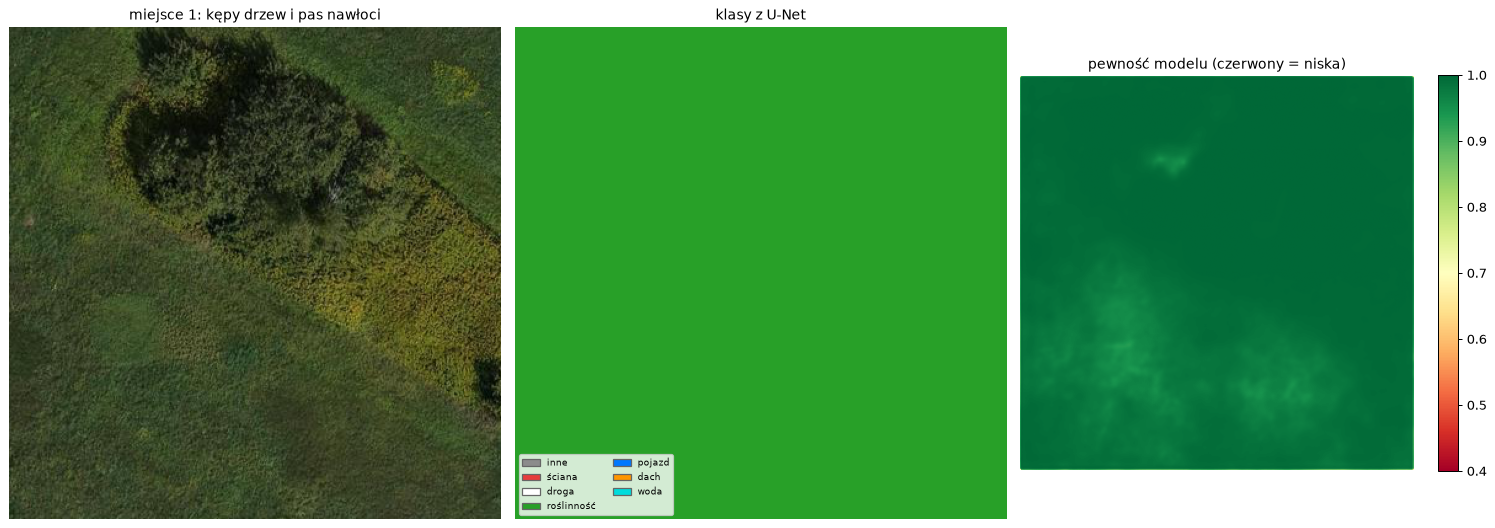

czarne tło w kadrze: 0% | średnia pewność na ważnych pikselach: 0.990


,inne,ściana,droga,roślinność,pojazd,dach,woda
udział w kadrze [%],0.0,0.0,0.0,100.0,0.0,0.0,0.0


In [12]:
# ==================== ZMIEŃ TU ====================
NR_MIEJSCA = 1      # 1 = kępy drzew i nawłoć, 2 = koleiny drogi gruntowej, 3 = ściernisko i łąka, 4 = brzeg mozaiki (obok czarne tło)
# ===================================================

MIEJSCA = {1: (1250, 550, "kępy drzew i pas nawłoci"), 2: (1300, 50, "koleiny drogi gruntowej"),
           3: (100, 0, "ściernisko i łąka"), 4: (200, 1150, "brzeg mozaiki, obok czarne tło")}
w0, k0, opis = MIEJSCA[NR_MIEJSCA]
kadr = rgb_lom[w0:w0 + 400, k0:k0 + 400]
waznie_kadru = waznie_lom[w0:w0 + 400, k0:k0 + 400]

p = predykcja_kafelkami(model, kadr)                                   # slajd 14
klasy_kadru = np.where(waznie_kadru, p.argmax(0), 255)
pewnosc_kadru = np.where(waznie_kadru, p.max(0), np.nan)

fig, ax = plt.subplots(1, 3, figsize=(17, 5.8))
ax[0].imshow(kadr); ax[0].set_title(f"miejsce {NR_MIEJSCA}: {opis}"); ax[0].axis("off")
pokaz_klasy(ax[1], klasy_kadru, "klasy z U-Net"); ax[1].legend(handles=legenda(), loc="lower left", fontsize=7, ncol=2)
obraz = ax[2].imshow(pewnosc_kadru, cmap="RdYlGn", vmin=0.4, vmax=1); ax[2].set_title("pewność modelu (czerwony = niska)"); ax[2].axis("off")
plt.colorbar(obraz, ax=ax[2], shrink=0.8)
plt.tight_layout(); plt.show()

udzial = np.bincount(klasy_kadru[waznie_kadru], minlength=N_KLAS) / waznie_kadru.sum() * 100
print(f"czarne tło w kadrze: {(~waznie_kadru).mean():.0%} | średnia pewność na ważnych pikselach: {np.nanmean(pewnosc_kadru):.3f}")
pd.DataFrame({"udział w kadrze [%]": udzial.round(2)}, index=NAZWY_KLAS).T

### Zadanie 4. Ustawienia predykcji: zakładka i TTA

Na Łomiankach prawie wszystko jest „roślinnością", więc zmiana ustawień nic by tu nie pokazała. Dlatego to zadanie robisz na **fragmencie Tapias z zabudową**: tym samym, który widzisz na slajdzie 18.
Sprawdzasz, jak wynik zależy od dwóch ustawień ze **slajdu 14**: **kroku kafelków** (im mniejszy, tym większa zakładka) i **TTA** (uśrednianie z odbiciem lustrzanym).
Każdy wariant to jeden wiersz na liście. **Pierwszy wiersz zostaw:** z nim porównujemy resztę.


,wariant,krok,TTA,czas [s],różni się od pierwszego [% pikseli],dach [% kadru],średnia pewność
0,domyślny (jak na wykładzie),128,True,0.06,0.00,3.52,0.871
1,bez TTA,128,False,0.03,3.42,4.34,0.883
2,bez zakładki,256,True,0.26,1.08,3.69,0.874
3,gęsta zakładka,64,True,0.14,0.57,3.43,0.871


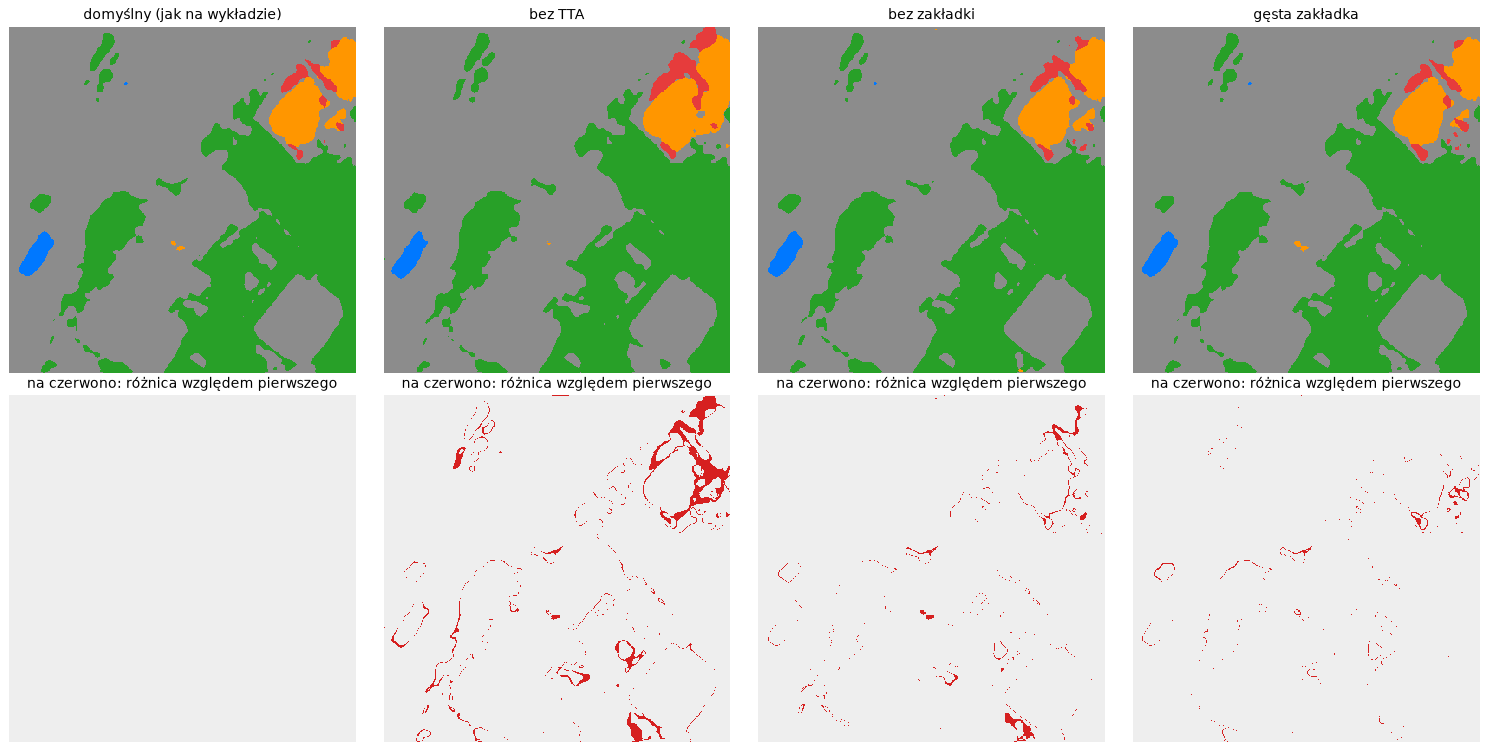

In [13]:
# ==================== ZMIEŃ TU ====================
# Każdy wiersz to wariant: (nazwa, krok kafelków, czy uśredniać z odbiciem TTA). Pierwszy wiersz zostaw bez zmian.
WARIANTY = [
    ("domyślny (jak na wykładzie)", 128, True),
    ("bez TTA",                    128, False),
    ("bez zakładki",               256, True),
    ("gęsta zakładka",              64, True),
]
# ===================================================

FRAGMENT = np.s_[850:1250, 1000:1400]          # okolice zabudowy w Tapias (400 x 400 px)
kadr_tap = rgb_tap[FRAGMENT]
predykcja_kafelkami(model, kadr_tap[:256, :256])           # rozgrzewka (pierwsze wywołanie na GPU jest wolniejsze)

wyniki_wariantow = []
for nazwa, krok, tta in WARIANTY:
    t0 = time.perf_counter()
    pw = predykcja_kafelkami(model, kadr_tap, krok=krok, tta=tta)
    wyniki_wariantow.append({"nazwa": nazwa, "krok": krok, "tta": tta, "czas": time.perf_counter() - t0,
                             "klasy": pw.argmax(0), "pewnosc": pw.max(0)})

bazowa = wyniki_wariantow[0]["klasy"]
tabela = pd.DataFrame([{"wariant": v["nazwa"], "krok": v["krok"], "TTA": v["tta"], "czas [s]": round(v["czas"], 2),
                        "różni się od pierwszego [% pikseli]": round(float((v["klasy"] != bazowa).mean() * 100), 2),
                        "dach [% kadru]": round(float((v["klasy"] == NAZWY_KLAS.index("dach")).mean() * 100), 2),
                        "średnia pewność": round(float(v["pewnosc"].mean()), 3)} for v in wyniki_wariantow])
display(tabela)

n = len(wyniki_wariantow)
fig, ax = plt.subplots(2, n, figsize=(4.2 * n, 8.4), squeeze=False)
for j, v in enumerate(wyniki_wariantow):
    pokaz_klasy(ax[0, j], v["klasy"], v["nazwa"])
    ax[1, j].imshow(np.where(v["klasy"] != bazowa, 0, 1), cmap=ListedColormap(["#d62020", "#eeeeee"]), vmin=0, vmax=1, interpolation="nearest")
    ax[1, j].set_title("na czerwono: różnica względem pierwszego"); ax[1, j].axis("off")
plt.tight_layout(); plt.show()

> **Podpowiedź.** Możesz dopisać własny wiersz, np. `("krok 32 bez TTA", 32, False)`. Pamiętaj o przecinku na końcu wiersza.

### Zadanie 5. Prawdopodobieństwa klas i pewność

Model nie „widzi" klas, tylko liczy dla każdej prawdopodobieństwo. Tu możesz je obejrzeć **na całym zdjęciu z Łomianek**: wybierz klasę i zobacz, gdzie model uważa, że ona jest (jasny = wysokie prawdopodobieństwo).
Drugi wykres pokazuje na żółto miejsca, w których model jest **pewny na mniej niż wybrany próg** (slajd 18).


In [14]:
# GOTOWE: prawdopodobieństwa klas dla całego zdjęcia z Łomianek (kilka sekund)
p_lom = predykcja_kafelkami(model, rgb_lom)          # (7, wysokość, szerokość)
pewnosc_lom = p_lom.max(0)                            # pewność = największe prawdopodobieństwo
print("Gotowe:", p_lom.shape, "| średnia pewność na ważnych pikselach:", round(float(pewnosc_lom[waznie_lom].mean()), 3))

Gotowe: (7, 1700, 1700) | średnia pewność na ważnych pikselach: 0.984


Najwyższe prawdopodobieństwo klasy 'woda' na zdjęciu: 0.80
Pikseli, gdzie 'woda' ma prawdopodobieństwo > 0,5: 735 (7 m2)
Niepewne (pewność < 0.9): 2.7% zdjęcia


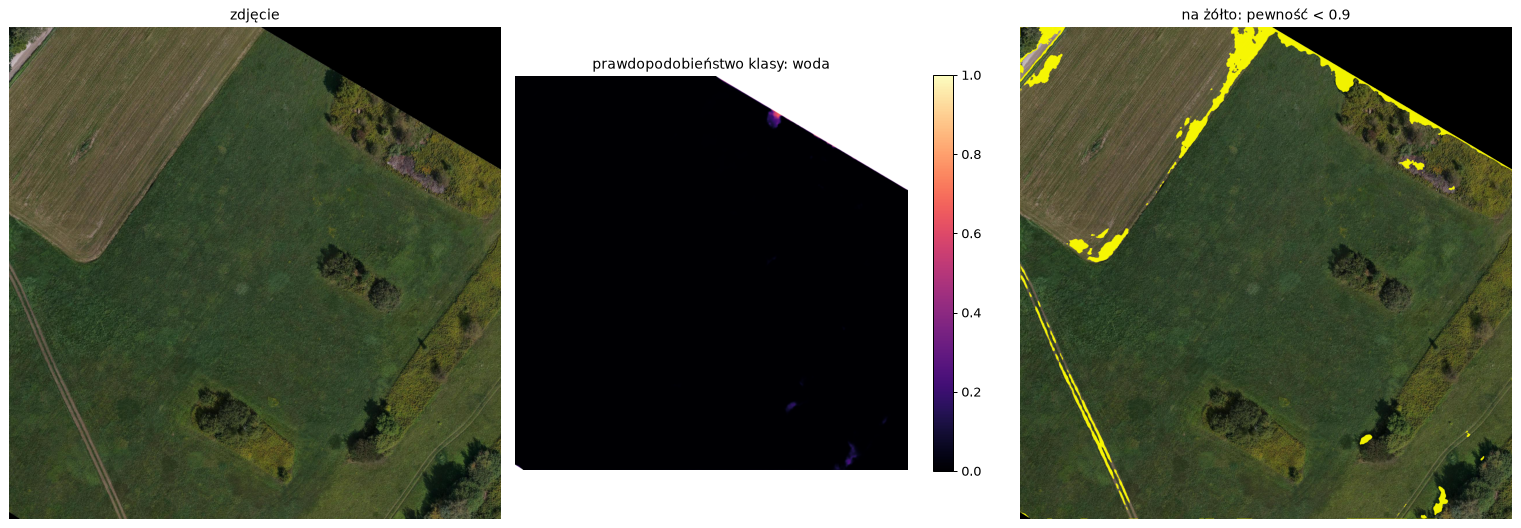

In [21]:
# ==================== ZMIEŃ TU ====================
KLASA = "woda"           # którą klasę pokazać: inne, ściana, droga, roślinność, pojazd, dach, woda
PROG_PEWNOSCI = 0.90     # zaznacz miejsca, w których pewność modelu jest niższa niż to (liczba od 0 do 1)
# ===================================================

k = NAZWY_KLAS.index(KLASA)
niepewne = waznie_lom & (pewnosc_lom < PROG_PEWNOSCI)
print(f"Najwyższe prawdopodobieństwo klasy '{KLASA}' na zdjęciu: {p_lom[k][waznie_lom].max():.2f}")
print(f"Pikseli, gdzie '{KLASA}' ma prawdopodobieństwo > 0,5: {(p_lom[k][waznie_lom] > 0.5).sum()} ({(p_lom[k][waznie_lom] > 0.5).sum() * gsd_lom ** 2:.0f} m2)")
print(f"Niepewne (pewność < {PROG_PEWNOSCI}): {niepewne.sum() / waznie_lom.sum():.1%} zdjęcia")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.8))
ax[0].imshow(rgb_lom); ax[0].set_title("zdjęcie"); ax[0].axis("off")
obraz = ax[1].imshow(np.where(waznie_lom, p_lom[k], np.nan), vmin=0, vmax=1, cmap="magma")
ax[1].set_title(f"prawdopodobieństwo klasy: {KLASA}"); ax[1].axis("off"); plt.colorbar(obraz, ax=ax[1], shrink=0.8)
ax[2].imshow(rgb_lom); ax[2].imshow(np.ma.masked_where(~niepewne, niepewne), cmap=ListedColormap(["yellow"]), alpha=0.95)
ax[2].set_title(f"na żółto: pewność < {PROG_PEWNOSCI}"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Krok 3. Całość do GeoTIFF-a

### Zadanie 6. Cały ortomozaik: GeoTIFF z klasami i pewnością

Teraz to samo na **całym zdjęciu** i z zapisem na dysk (slajd 17). Funkcja `segmentuj_ortomozaik` idzie blokami 1024 px z marginesem 128 px, zachowuje georeferencję,
dokłada paletę kolorów klas i zapisuje osobny plik z pewnością. Wynik możesz od razu otworzyć w QGIS-ie (zadanie 10).
Druga komórka to **kontrola**, którą robisz przed oddaniem każdego wyniku: czy plik leży dokładnie na siatce zdjęcia.


In [ ]:
# GOTOWE: segmentacja całego zdjęcia z Łomianek → dwa pliki GeoTIFF
WYJ_KLASY = KATALOG / "lomianki_klasy.tif"
WYJ_PEWNOSC = KATALOG / "lomianki_pewnosc.tif"

t0 = time.perf_counter()
piksele, gsd = segmentuj_ortomozaik(LOMIANKI, WYJ_KLASY, WYJ_PEWNOSC, model)
czas_ortomozaik = time.perf_counter() - t0
print(f"Gotowe w {czas_ortomozaik:.0f} s → {WYJ_KLASY}, {WYJ_PEWNOSC}")

klasy_lom = wczytaj_raster(WYJ_KLASY)
tabela_lom = tabela_klas(klasy_lom, gsd)
print(f"Powierzchnia zdjęcia (ważne piksele): {waznie_lom.sum() * gsd ** 2 / 1e4:.2f} ha")
tabela_lom

Gotowe w 1 s → wyniki/zadania_unet/lomianki_klasy.tif, wyniki/zadania_unet/lomianki_pewnosc.tif
Powierzchnia zdjęcia (ważne piksele): 2.68 ha


,powierzchnia [ha],udział [%]
inne,0.010,0.38
ściana,0.000,0.00
droga,0.000,0.00
roślinność,2.674,99.58
pojazd,0.000,0.00
dach,0.000,0.00
woda,0.001,0.04


1. Ten sam układ i siatka: EPSG:32634, 1700 x 1700 px, piksel 0.100 m
2. Lewy górny róg piksela (0, 0): zdjęcie (np.float64(490586.9070320702), np.float64(5801887.4489656165)), wynik (np.float64(490586.9070320702), np.float64(5801887.4489656165))
3. Brak danych (255) dokładnie tam, gdzie czarne tło zdjęcia: True
4. Zgodność z predykcją całego zdjęcia naraz (zadanie 5): 100.00% (szwów między blokami brak, gdy ~100%)


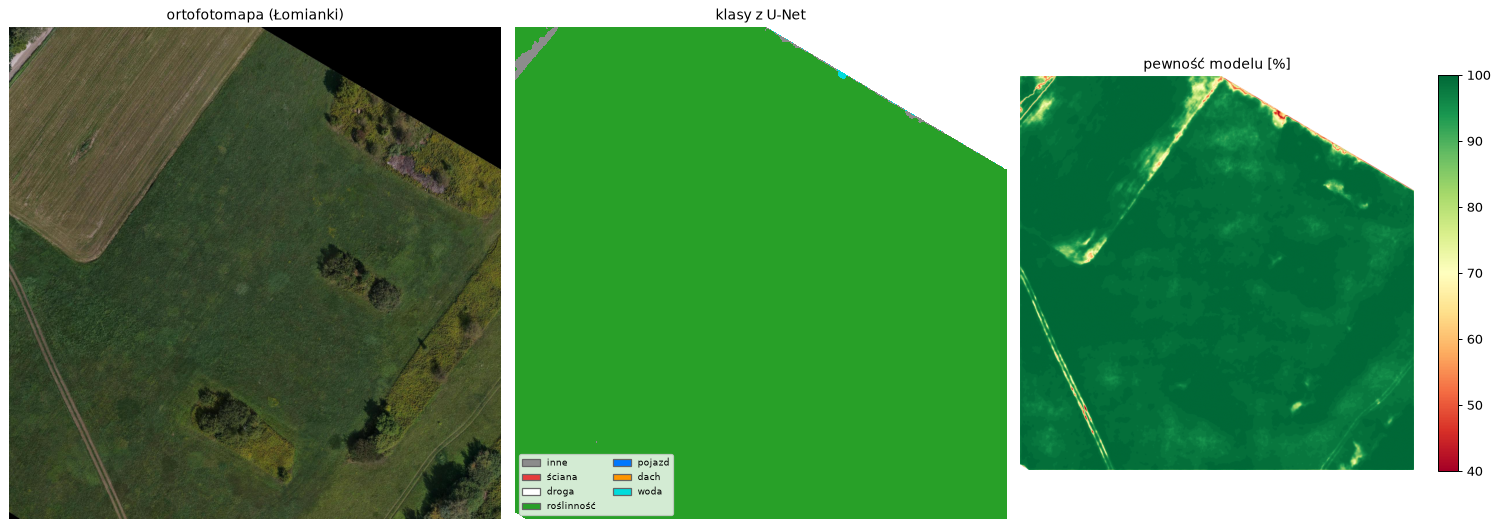

In [ ]:
# GOTOWE: kontrola przed oddaniem wyniku
with rasterio.open(LOMIANKI) as a, rasterio.open(WYJ_KLASY) as b:
    assert a.crs == b.crs and a.transform == b.transform and a.shape == b.shape, "wynik nie leży na siatce zdjęcia!"
    print(f"1. Ten sam układ i siatka: {b.crs}, {b.width} x {b.height} px, piksel {b.res[0]:.3f} m")
    print(f"2. Lewy górny róg piksela (0, 0): zdjęcie {a.xy(0, 0)}, wynik {b.xy(0, 0)}")
print(f"3. Brak danych (255) dokładnie tam, gdzie czarne tło zdjęcia: {bool(((klasy_lom == 255) == ~waznie_lom).all())}")
zgodnosc = (p_lom.argmax(0)[waznie_lom] == klasy_lom[waznie_lom]).mean()
print(f"4. Zgodność z predykcją całego zdjęcia naraz (zadanie 5): {zgodnosc:.2%} (szwów między blokami brak, gdy ~100%)")

fig, ax = plt.subplots(1, 3, figsize=(17, 5.8))
ax[0].imshow(rgb_lom); ax[0].set_title("ortofotomapa (Łomianki)"); ax[0].axis("off")
pokaz_klasy(ax[1], klasy_lom, "klasy z U-Net"); ax[1].legend(handles=legenda(), loc="lower left", fontsize=7, ncol=2)
pewnosc_zapisana = wczytaj_raster(WYJ_PEWNOSC)
obraz = ax[2].imshow(np.ma.masked_equal(pewnosc_zapisana, 255), cmap="RdYlGn", vmin=40, vmax=100)
ax[2].set_title("pewność modelu [%]"); ax[2].axis("off"); plt.colorbar(obraz, ax=ax[2], shrink=0.8)
plt.tight_layout(); plt.show()